# Call Center Operator Efficiency Analysis

**Project Date:** January 2026

## Objective

The objective of this project is to analyze call center operational data to identify potentially inefficient operators based on missed inbound calls, average wait time, outbound activity, and overall call handling performance.

## Dataset

- Source: TripleTen / CallMeMaybe dataset
- Records analyzed: 53,000+ call records
- Data includes:
  - Call direction
  - Call duration
  - Wait time
  - Missed calls
  - Operator activity
  - Internal and external calls

## Tools

- Python
- pandas
- NumPy
- matplotlib
- seaborn
- scipy.stats
- Tableau
- Google Colab

## Stakeholders

The results of this analysis may support decision-making across multiple business functions:

- **Operations Managers:** Monitor operator performance and optimize workload allocation.
- **Team Supervisors:** Identify operators requiring coaching or performance support.
- **Human Resources:** Support training initiatives and workforce development programs.
- **Leadership Teams:** Monitor operational efficiency and customer service performance through KPI reporting.

## Data Loading and Initial Exploration

The datasets were loaded and reviewed to evaluate their structure, data types, missing values, duplicate records, and overall data quality before starting the analysis.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Dataset paths
BASE_PATH = '/content/drive/MyDrive/TripleTen/Projects/Call_Center_Operator_Efficiency_Analysis/Datasets'

# Load datasets
telecom_data = pd.read_csv(
    f'{BASE_PATH}/telecom_dataset_new.csv'
)

clients_data = pd.read_csv(
    f'{BASE_PATH}/telecom_clients.csv'
)

In [ ]:
# Dataset dimensions
print("Telecom dataset dimensions:", telecom_data.shape)
print("Clients dataset dimensions:", clients_data.shape)

Telecom dataset dimensions: (53902, 9)
Clients dataset dimensions: (732, 3)


In [ ]:
# Dataset structure and data types
print("Telecom dataset information:")
telecom_data.info()

print("\nClients dataset information:")
clients_data.info()

Telecom dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

Clients dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-

In [ ]:
# Descriptive statistics
print("Descriptive statistics for telecom dataset:")
print(telecom_data.describe())

Descriptive statistics for telecom dataset:
             user_id    operator_id   calls_count  call_duration  \
count   53902.000000   45730.000000  53902.000000   53902.000000   
mean   167295.344477  916535.993002     16.451245     866.684427   
std       598.883775   21254.123136     62.917170    3731.791202   
min    166377.000000  879896.000000      1.000000       0.000000   
25%    166782.000000  900788.000000      1.000000       0.000000   
50%    167162.000000  913938.000000      4.000000      38.000000   
75%    167819.000000  937708.000000     12.000000     572.000000   
max    168606.000000  973286.000000   4817.000000  144395.000000   

       total_call_duration  
count         53902.000000  
mean           1157.133297  
std            4403.468763  
min               0.000000  
25%              47.000000  
50%             210.000000  
75%             902.000000  
max          166155.000000  


In [ ]:
# Missing values
print("Missing values in telecom_data:")
print(telecom_data.isnull().sum())

print("\nMissing values in clients_data:")
print(clients_data.isnull().sum())

Missing values in telecom_data:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Missing values in clients_data:
user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [ ]:
# Duplicate records
print("Number of duplicate records in telecom_data:",
      telecom_data.duplicated().sum())

print("Number of duplicate records in clients_data:",
      clients_data.duplicated().sum())

Number of duplicate records in telecom_data: 4900
Number of duplicate records in clients_data: 0


Initial exploration showed the presence of missing values, duplicate records, and data consistency issues that required cleaning before performing operator-level KPI analysis.

## Data Cleaning

Data cleaning steps were performed to improve consistency, remove duplicate records, handle missing values, and prepare the dataset for operator-level KPI analysis.

In [ ]:
# Create working copies
telecom_data_clean = telecom_data.copy()
clients_data_clean = clients_data.copy()

In [ ]:
# Convert date columns to datetime format
telecom_data_clean['date'] = pd.to_datetime(telecom_data_clean['date'])
clients_data_clean['date_start'] = pd.to_datetime(clients_data_clean['date_start'])

In [ ]:
# Fill missing internal call values as False
telecom_data_clean['internal'] = (
    telecom_data_clean['internal']
    .fillna(False)
    .astype(bool)
)

/tmp/ipykernel_1243/2477981149.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [ ]:
# Remove duplicate records based on event-level columns
duplicates_before = telecom_data_clean.duplicated().sum()

event_cols = [
    'user_id',
    'date',
    'direction',
    'internal',
    'operator_id',
    'is_missed_call',
    'calls_count',
    'call_duration',
    'total_call_duration'
]

telecom_data_clean = (
    telecom_data_clean
    .drop_duplicates(subset=event_cols)
    .reset_index(drop=True)
)

duplicates_after = telecom_data_clean.duplicated().sum()

print("Duplicate records before cleaning:", duplicates_before)
print("Duplicate records after cleaning:", duplicates_after)

Duplicate records before cleaning: 4900
Duplicate records after cleaning: 0


In [ ]:
# Create a subset for operator-level analysis
telecom_ops = telecom_data_clean.dropna(
    subset=['operator_id']
).copy()

# Convert operator_id to integer format
telecom_ops['operator_id'] = telecom_ops['operator_id'].astype('int64')

In [ ]:
# Calculate wait time per record
telecom_ops['wait_time'] = (
    telecom_ops['total_call_duration'] -
    telecom_ops['call_duration']
)

# Create inbound and outbound call volume variables
telecom_ops['inbound_calls'] = np.where(
    telecom_ops['direction'] == 'in',
    telecom_ops['calls_count'],
    0
)

telecom_ops['outbound_calls'] = np.where(
    telecom_ops['direction'] == 'out',
    telecom_ops['calls_count'],
    0
)

# Create missed and answered inbound call variables
telecom_ops['missed_inbound_calls'] = np.where(
    (telecom_ops['direction'] == 'in') &
    (telecom_ops['is_missed_call']),
    telecom_ops['calls_count'],
    0
)

telecom_ops['answered_inbound_calls'] = np.where(
    (telecom_ops['direction'] == 'in') &
    (~telecom_ops['is_missed_call']),
    telecom_ops['calls_count'],
    0
)

# Calculate wait time only for inbound calls
telecom_ops['wait_time_inbound'] = np.where(
    telecom_ops['direction'] == 'in',
    telecom_ops['wait_time'],
    np.nan
)

In [ ]:
# Validate dataset dimensions after cleaning
print("Original telecom_data shape:", telecom_data.shape)
print("Cleaned telecom_data shape:", telecom_data_clean.shape)
print("Operator-level analysis subset shape:", telecom_ops.shape)

Original telecom_data shape: (53902, 9)
Cleaned telecom_data shape: (49002, 9)
Operator-level analysis subset shape: (41546, 15)


After cleaning, duplicate records were removed, date columns were converted to datetime format, missing values in `internal` were handled, and records without `operator_id` were excluded from the operator-level analysis.

Additional variables were created to support KPI calculation, including inbound calls, outbound calls, missed inbound calls, answered inbound calls, and inbound wait time.

## Data Dictionary and Cleaning Rules

The following table summarizes the main fields used in the analysis, their expected data types, missing values, and cleaning actions applied during data preparation.

In [ ]:
# Data dictionary and cleaning rules
data_dictionary = {
    "user_id": {
        "data_type": "int64",
        "description": "Unique user identifier",
        "missing_values": 0,
        "cleaning_action": "No action required"
    },
    "date": {
        "data_type": "datetime64[ns]",
        "description": "Call date",
        "missing_values": 0,
        "cleaning_action": "Converted to datetime format"
    },
    "direction": {
        "data_type": "object",
        "description": "Call direction: inbound ('in') or outbound ('out')",
        "missing_values": 0,
        "cleaning_action": "Validated expected values"
    },
    "internal": {
        "data_type": "bool",
        "description": "Indicates whether the call was internal",
        "missing_values": 117,
        "cleaning_action": "Missing values filled as False and converted to boolean"
    },
    "operator_id": {
        "data_type": "int64 / category",
        "description": "Operator identifier",
        "missing_values": 8172,
        "cleaning_action": "Records without operator_id excluded from operator-level KPI analysis"
    },
    "is_missed_call": {
        "data_type": "bool",
        "description": "Indicates whether the call was missed",
        "missing_values": 0,
        "cleaning_action": "No action required"
    },
    "calls_count": {
        "data_type": "int64",
        "description": "Number of calls represented by each record",
        "missing_values": 0,
        "cleaning_action": "Used as the unit for call volume calculations"
    },
    "call_duration": {
        "data_type": "int64",
        "description": "Call duration excluding wait time, in seconds",
        "missing_values": 0,
        "cleaning_action": "Used to calculate wait time"
    },
    "total_call_duration": {
        "data_type": "int64",
        "description": "Total call duration including wait time, in seconds",
        "missing_values": 0,
        "cleaning_action": "Used to calculate wait time"
    }
}

data_dictionary_df = pd.DataFrame(data_dictionary).T

data_dictionary_df

,data_type,description,missing_values,cleaning_action
user_id,int64,Unique user identifier,0,No action required
date,datetime64[ns],Call date,0,Converted to datetime format
direction,object,Call direction: inbound ('in') or outbound ('o...,0,Validated expected values
internal,bool,Indicates whether the call was internal,117,Missing values filled as False and converted t...
operator_id,int64 / category,Operator identifier,8172,Records without operator_id excluded from oper...
is_missed_call,bool,Indicates whether the call was missed,0,No action required
calls_count,int64,Number of calls represented by each record,0,Used as the unit for call volume calculations
call_duration,int64,"Call duration excluding wait time, in seconds",0,Used to calculate wait time
total_call_duration,int64,"Total call duration including wait time, in se...",0,Used to calculate wait time


Initial exploration and cleaning revealed missing values, duplicate records, and operator-level inconsistencies that required preprocessing before KPI calculation.

Records without `operator_id` were excluded only from operator-level analysis, while the original cleaned dataset was preserved for general exploratory analysis.

## Exploratory Data Analysis

Exploratory data analysis (EDA) was performed to better understand call distribution, operator activity, missed call patterns, and wait time behavior before building operator-level KPIs.


In [ ]:
# Create working copy for exploratory analysis
df_eda = telecom_data_clean.copy()

In [ ]:
# Distribution of internal vs external calls
print("Percentage distribution of internal vs external calls:")
print(
    df_eda['internal']
    .value_counts(normalize=True, dropna=False) * 100
)

print("\nCall counts for internal vs external calls:")
print(
    df_eda['internal']
    .value_counts(dropna=False)
)

Percentage distribution of internal vs external calls:
internal
False    88.463736
True     11.536264
Name: proportion, dtype: float64

Call counts for internal vs external calls:
internal
False    43349
True      5653
Name: count, dtype: int64


In [ ]:
# Distribution of inbound vs outbound calls
print("Percentage distribution of inbound vs outbound calls:")
print(
    df_eda['direction']
    .value_counts(normalize=True) * 100
)

print("\nCall counts for inbound vs outbound calls:")
print(
    df_eda['direction']
    .value_counts()
)

Percentage distribution of inbound vs outbound calls:
direction
out    59.179217
in     40.820783
Name: proportion, dtype: float64

Call counts for inbound vs outbound calls:
direction
out    28999
in     20003
Name: count, dtype: int64


In [ ]:
# Cross-analysis between call direction and internal calls
print("Direction distribution by internal call type (% by row):")

direction_internal_pct = (
    pd.crosstab(
        df_eda['internal'],
        df_eda['direction'],
        normalize='index'
    ) * 100
)

print(direction_internal_pct)

print("\nDirection counts by internal call type:")

direction_internal_counts = pd.crosstab(
    df_eda['internal'],
    df_eda['direction']
)

print(direction_internal_counts)

Direction distribution by internal call type (% by row):
direction         in        out
internal                       
False      44.596184  55.403816
True       11.869804  88.130196

Direction counts by internal call type:
direction     in    out
internal               
False      19332  24017
True         671   4982


In [ ]:
# Function for robust statistical summary
def robust_summary(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    return pd.Series({
        "min": series.min(),
        "q1": q1,
        "median": series.median(),
        "q3": q3,
        "max": series.max(),
        "iqr": q3 - q1
    })

In [ ]:
# Descriptive statistics for call durations
print("Descriptive statistics for call durations:")
print(
    df_eda[
        ['call_duration', 'total_call_duration']
    ].describe()
)

print("\nRobust summary for call_duration:")
print(
    robust_summary(df_eda['call_duration'])
)

print("\nRobust summary for total_call_duration:")
print(
    robust_summary(df_eda['total_call_duration'])
)

Descriptive statistics for call durations:
       call_duration  total_call_duration
count   49002.000000         49002.000000
mean      866.282091          1156.558202
std      3775.503352          4451.473661
min         0.000000             0.000000
25%         0.000000            46.000000
50%        37.000000           208.000000
75%       570.000000           901.000000
max    144395.000000        166155.000000

Robust summary for call_duration:
min            0.0
q1             0.0
median        37.0
q3           570.0
max       144395.0
iqr          570.0
dtype: float64

Robust summary for total_call_duration:
min            0.0
q1            46.0
median       208.0
q3           901.0
max       166155.0
iqr          855.0
dtype: float64


In [ ]:
# Descriptive statistics for calls_count
print("Descriptive statistics for calls_count:")
print(
    df_eda['calls_count'].describe()
)

print("\nRobust summary for calls_count:")
print(
    robust_summary(df_eda['calls_count'])
)

Descriptive statistics for calls_count:
count    49002.000000
mean        16.462777
std         63.604098
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
max       4817.000000
Name: calls_count, dtype: float64

Robust summary for calls_count:
min          1.0
q1           1.0
median       4.0
q3          12.0
max       4817.0
iqr         11.0
dtype: float64


In [ ]:
# Missed calls analysis
print("Overall missed call percentage:")
print(
    df_eda['is_missed_call']
    .value_counts(normalize=True) * 100
)

print("\nMissed call percentage by direction:")

missed_calls_by_direction = (
    df_eda
    .groupby('direction')['is_missed_call']
    .mean() * 100
)

print(missed_calls_by_direction)

Overall missed call percentage:
is_missed_call
False    56.220154
True     43.779846
Name: proportion, dtype: float64

Missed call percentage by direction:
direction
in     39.429086
out    46.780923
Name: is_missed_call, dtype: float64


### EDA Findings

External calls represented the majority of the operational workload, accounting for approximately 88.5% of all records (43,349 calls). This suggests that operator performance directly impacts customer-facing interactions and overall service quality.

Outbound calls represented 59.2% of activity, while inbound calls accounted for 40.8%. Since the business objective focuses on missed inbound calls and inbound wait times, subsequent KPI analysis prioritizes inbound operational performance.

Cross-analysis between `internal` and `direction` showed that internal calls were predominantly outbound (88.1%), which is consistent with internal coordination activity between operators.

Call duration variables presented highly skewed distributions and significant outliers:
- `call_duration` median: 37 seconds
- `total_call_duration` median: 208 seconds
- Maximum values exceeded 140K seconds

Due to the presence of extreme values, robust statistics such as median and interquartile range (IQR) were prioritized during the analysis instead of relying only on averages.

The `calls_count` variable also showed substantial variability, with a median of 4 calls and maximum values reaching 4,817 calls per record. This reinforced the importance of using consistent aggregation logic for KPI calculations.

Missed calls represented approximately 43.8% of all records overall. However, because the operational analysis focused on customer service quality, the next stages prioritized inbound missed call rates and inbound wait times at the operator level.

## KPI Development

Operator-level KPIs were developed to evaluate call handling performance and identify potentially inefficient operators based on operational business thresholds.


The following metrics were calculated for each `operator_id`:

- Total inbound calls
- Total outbound calls
- Missed inbound calls
- Answered inbound calls
- Missed inbound call rate
- Average inbound wait time
- Total calls handled

In [ ]:
# Calculate operator-level metrics using cleaned data
metrics_by_operator = (
    telecom_ops
    .groupby('operator_id')
    .agg(
        inbound_calls=('inbound_calls', 'sum'),
        outbound_calls=('outbound_calls', 'sum'),
        missed_inbound_calls=('missed_inbound_calls', 'sum'),
        answered_inbound_calls=('answered_inbound_calls', 'sum'),
        avg_call_duration=('call_duration', 'mean'),
        avg_total_call_duration=('total_call_duration', 'mean'),
        avg_wait_time=('wait_time_inbound', 'mean')
    )
    .reset_index()
)

# Calculate total inbound attempts
metrics_by_operator['inbound_attempts'] = (
    metrics_by_operator['missed_inbound_calls'] +
    metrics_by_operator['answered_inbound_calls']
)

# Calculate missed inbound call rate
metrics_by_operator['pct_missed_calls'] = np.where(
    metrics_by_operator['inbound_attempts'] > 0,
    metrics_by_operator['missed_inbound_calls'] /
    metrics_by_operator['inbound_attempts'],
    np.nan
)

# Calculate total calls handled
metrics_by_operator['total_calls_handled'] = (
    metrics_by_operator['inbound_attempts'] +
    metrics_by_operator['outbound_calls']
)

metrics_by_operator.head().round(2)

,operator_id,inbound_calls,outbound_calls,missed_inbound_calls,answered_inbound_calls,avg_call_duration,avg_total_call_duration,avg_wait_time,inbound_attempts,pct_missed_calls,total_calls_handled
0,879896,58,872,0,58,545.83,650.74,27.33,58,0.0,930
1,879898,104,7209,0,104,1133.88,1591.58,29.47,104,0.0,7313
2,880020,7,38,0,7,112.25,126.25,7.71,7,0.0,45
3,880022,8,189,0,8,216.39,270.36,14.00,8,0.0,197
4,880026,24,2208,0,24,842.45,964.43,7.94,24,0.0,2232


The operator-level table summarizes the main KPIs used to evaluate performance, including missed inbound call rate, average wait time, outbound activity, and total call volume.

### KPI Definitions

Operator-level KPIs were calculated using `calls_count` as the primary unit of measurement to ensure consistency across aggregated call records.

The following metrics were developed:

- **Inbound calls / Outbound calls:** Total inbound and outbound call volume per operator.
- **Missed inbound calls:** Total inbound calls marked as missed.
- **Answered inbound calls:** Total inbound calls successfully answered.
- **Inbound attempts:** Total inbound call attempts (`answered + missed`).
- **Missed inbound call rate (`pct_missed_calls`):**  
  Calculated as:

  `missed_inbound_calls / inbound_attempts`

  This approach avoids mixing row counts with actual call volume when `calls_count > 1`.

- **Average wait time (`avg_wait_time`):**  
  Calculated as:

  `total_call_duration - call_duration`

  and averaged only for inbound calls, where customer wait time is operationally relevant.

- **Total calls handled:** Combined inbound and outbound call volume managed by each operator.

These KPIs were used to compare operator performance and evaluate operational efficiency against predefined business thresholds.

## Identifying Inefficient Operators

Operator performance was evaluated using operational business thresholds designed to identify potentially inefficient call handling behavior.

The analysis focused on operators showing one or more of the following patterns:

- High missed inbound call rate
- High inbound wait times
- Low outbound call activity


### Business Thresholds

The following thresholds were used to identify potentially inefficient operators:

- Missed inbound call rate greater than 10%
- Average inbound wait time greater than 180 seconds
- Outbound call volume below 80% of the overall system average

In [ ]:
# Calculate average outbound activity
outbound_mean = metrics_by_operator.loc[
    metrics_by_operator['outbound_calls'] > 0,
    'outbound_calls'
].mean()

# Flag operators with low outbound activity
metrics_by_operator['low_outbound_activity'] = np.where(
    (
        metrics_by_operator['outbound_calls'] > 0
    ) &
    (
        metrics_by_operator['outbound_calls'] <
        0.8 * outbound_mean
    ),
    True,
    False
)

In [ ]:
# Calculate outbound activity threshold
outbound_threshold = 0.8 * outbound_mean

print("Average outbound calls:", round(outbound_mean, 2))
print("Low outbound activity threshold (80% of average):",
      round(outbound_threshold, 2))

Average outbound calls: 689.73
Low outbound activity threshold (80% of average): 551.79


In [ ]:
# Identify potentially inefficient operators
inefficient_operators = metrics_by_operator[
    (
        metrics_by_operator['pct_missed_calls'] > 0.10
    ) |
    (
        metrics_by_operator['avg_wait_time'] > 180
    ) |
    (
        metrics_by_operator['low_outbound_activity']
    )
]

print("Potentially inefficient operators:")

inefficient_operators[
    [
        'operator_id',
        'pct_missed_calls',
        'avg_wait_time',
        'inbound_attempts',
        'outbound_calls',
        'total_calls_handled'
    ]
].head(20).round(2)

Potentially inefficient operators:


,operator_id,pct_missed_calls,avg_wait_time,inbound_attempts,outbound_calls,total_calls_handled
2,880020,0.00,7.71,7,38,45
3,880022,0.00,14.00,8,189,197
6,880240,NaN,NaN,0,47,47
7,881278,NaN,NaN,0,20,20
9,882478,0.00,38.00,3,1,4
11,882684,0.01,190.52,613,661,1274
13,882688,0.00,336.50,15,43,58
14,882690,0.01,322.82,171,1417,1588
15,883018,NaN,NaN,0,2,2
16,883898,NaN,NaN,0,1,1


Operators were classified as potentially inefficient when they exceeded at least one predefined business threshold related to missed inbound calls, inbound wait times, or outbound activity.

The resulting group included operators with:
- Missed inbound call rates above 10%
- Average inbound wait times exceeding 180 seconds
- Outbound activity significantly below the system average

In cases where `inbound_attempts = 0`, metrics such as `pct_missed_calls` and `avg_wait_time` remained undefined (`NaN`) because no inbound calls were handled. In these situations, operator classification depended exclusively on outbound activity thresholds.

## Future Analytical Opportunities

This project was developed using a rule-based operational approach to identify potentially inefficient operators.

Future iterations of the analysis could explore:
- Operator segmentation using clustering techniques
- Predictive models for operator performance monitoring
- Automated anomaly detection for operational KPIs

However, the current rule-based framework provides an interpretable and business-aligned baseline for operational performance evaluation.

## Statistical Analysis

Statistical hypothesis testing was performed to evaluate whether potentially inefficient operators showed significantly different operational behavior compared to the rest of the operator population.

The analysis focused on:
- Missed inbound call rates
- Average inbound wait times

The objective was to determine whether observed performance differences were statistically significant rather than the result of random variation.


### Missed Inbound Call Rate Validation

A statistical proportion test was performed to evaluate whether the overall missed inbound call rate differed significantly from the operational threshold of 10%.

In [ ]:
from scipy import stats
import numpy as np

# Define operational threshold
target_missed_call_rate = 0.10

# Aggregate inbound call metrics across operators
total_missed_calls = (
    metrics_by_operator['missed_inbound_calls']
    .sum()
)

total_inbound_attempts = (
    metrics_by_operator['inbound_attempts']
    .sum()
)

# Observed missed call rate
observed_missed_call_rate = (
    total_missed_calls /
    total_inbound_attempts
)

# One-sample z-test for proportions
standard_error = np.sqrt(
    target_missed_call_rate *
    (1 - target_missed_call_rate) /
    total_inbound_attempts
)

z_statistic = (
    observed_missed_call_rate -
    target_missed_call_rate
) / standard_error

p_value = 2 * (
    1 - stats.norm.cdf(abs(z_statistic))
)

# Results
print(
    f"Observed missed inbound call rate: "
    f"{observed_missed_call_rate:.4f}"
)

print(f"Z-statistic: {z_statistic:.3f}")

print(f"P-value: {p_value:.4f}")

Observed missed inbound call rate: 0.0099
Z-statistic: -92.012
P-value: 0.0000


The statistical test indicated that the observed missed inbound call rate differed significantly from the 10% operational benchmark.

This suggests that inbound missed call performance across the system may exceed the expected operational target and should be monitored as part of operator performance evaluation.

In [ ]:
from scipy import stats
import numpy as np

# H0₁: la proporción de llamadas entrantes perdidas es 10%
p0 = 0.10

# Agregamos a nivel global (todas las llamadas entrantes de todos los operadores)
total_missed = metrics_by_operator['missed_inbound_calls'].sum()
total_inbound = metrics_by_operator['inbound_attempts'].sum()

p_hat = total_missed / total_inbound

# Prueba z para una proporción
se = np.sqrt(p0 * (1 - p0) / total_inbound)      # error estándar bajo H0
z_stat = (p_hat - p0) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # prueba bilateral

print(f"Proporción observada de llamadas entrantes perdidas: {p_hat:.4f}")
print(f"Estadístico z: {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")

Proporción observada de llamadas entrantes perdidas: 0.0099
Estadístico z: -92.012
p-value: 0.0000


The z-test results showed an observed inbound missed call rate of approximately 0.99%, which was substantially below the operational benchmark of 10%.

The negative z-statistic and high p-value indicated that the observed missed call rate was not significantly greater than the predefined threshold. These results suggest that the overall inbound missed call performance across the system remained below the operational risk benchmark.

### Wait Time Comparison Across Operators

In [ ]:
from scipy import stats

# Filter inbound calls with valid wait times
df_wait = telecom_ops[
    (
        telecom_ops['direction'] == 'in'
    ) &
    (
        ~telecom_ops['wait_time_inbound'].isna()
    )
].copy()

# Include operators with a minimum number of inbound calls
MIN_INBOUND_CALLS = 30

valid_operators = (
    df_wait
    .groupby('operator_id')
    .size()
)

valid_operators = (
    valid_operators[
        valid_operators >= MIN_INBOUND_CALLS
    ].index
)

df_wait_filtered = df_wait[
    df_wait['operator_id'].isin(valid_operators)
]

# Create wait time groups by operator
groups = [
    group['wait_time_inbound'].values
    for _, group in df_wait_filtered.groupby('operator_id')
]

# Kruskal-Wallis test
h_statistic, p_value = stats.kruskal(*groups)

# Results
print(f"Kruskal-Wallis H-statistic: {h_statistic:.3f}")

print(f"P-value: {p_value:.4f}")

print(
    f"Operators included "
    f"(>= {MIN_INBOUND_CALLS} inbound calls): "
    f"{df_wait_filtered['operator_id'].nunique()}"
)

Kruskal-Wallis H-statistic: 3241.720
P-value: 0.0000
Operators included (>= 30 inbound calls): 159


The Kruskal-Wallis test was used to evaluate whether inbound wait times differed significantly across operators.

A non-parametric approach was selected due to the presence of skewed distributions and extreme outliers in wait time data.

To improve comparison stability, the analysis included only operators with at least 30 inbound calls (159 operators).

Since the p-value was below 0.05, the results indicated statistically significant differences in inbound wait times across operators.

From an operational perspective, these findings support the conclusion that wait time performance is not uniform across the system and that some operators demonstrate substantially higher wait times than others.

### Post-Hoc Wait Time Analysis

In [ ]:
# Summarize inbound wait time by operator
operator_wait_summary = (
    df_wait_filtered
    .groupby('operator_id')['wait_time_inbound']
    .agg(
        n_inbound='count',
        mean_wait='mean',
        median_wait='median'
    )
    .reset_index()
)

operator_wait_summary.head()

,operator_id,n_inbound,mean_wait,median_wait
0,879898,57,29.473684,14.0
1,880028,41,8.365854,7.0
2,882680,43,37.000000,30.0
3,882684,50,190.520000,173.0
4,882686,68,165.750000,106.5


In [ ]:
# Select top operators with the highest median wait time
TOP_OPERATORS = 15

top_wait_operators = (
    operator_wait_summary
    .sort_values('median_wait', ascending=False)
    .head(TOP_OPERATORS)['operator_id']
    .tolist()
)

print("Top operators selected for post-hoc analysis:")
print(top_wait_operators)

Top operators selected for post-hoc analysis:
[919794, 919790, 919552, 921318, 919554, 913938, 931458, 906406, 919792, 939762, 906404, 908958, 913942, 921818, 944218]


In [ ]:
# Reference group: all other operators
reference_wait_times = (
    df_wait_filtered[
        ~df_wait_filtered['operator_id'].isin(top_wait_operators)
    ]['wait_time_inbound']
    .dropna()
)

In [ ]:
# Mann-Whitney U test for each top operator
posthoc_results = []

for operator in top_wait_operators:

    operator_wait_times = (
        df_wait_filtered[
            df_wait_filtered['operator_id'] == operator
        ]['wait_time_inbound']
        .dropna()
    )

    u_statistic, p_value = stats.mannwhitneyu(
        operator_wait_times,
        reference_wait_times,
        alternative='greater'
    )

    # Common Language Effect Size
    effect_size = (
        u_statistic /
        (
            len(operator_wait_times) *
            len(reference_wait_times)
        )
    )

    posthoc_results.append({
        'operator_id': operator,
        'n_inbound': len(operator_wait_times),
        'median_wait': np.median(operator_wait_times),
        'mean_wait': np.mean(operator_wait_times),
        'p_value': p_value,
        'effect_size': effect_size
    })

posthoc_results_df = (
    pd.DataFrame(posthoc_results)
    .sort_values('p_value')
)

In [ ]:
# Adjust p-values using Holm correction
from statsmodels.stats.multitest import multipletests

reject, p_adjusted, _, _ = multipletests(
    posthoc_results_df['p_value'],
    method='holm'
)

posthoc_results_df['p_adj_holm'] = p_adjusted

posthoc_results_df['significant_0_05'] = reject

In [ ]:
# Display post-hoc results
posthoc_results_df[
    [
        'operator_id',
        'n_inbound',
        'median_wait',
        'mean_wait',
        'p_value',
        'p_adj_holm',
        'significant_0_05',
        'effect_size'
    ]
].head(15).round(3)

,operator_id,n_inbound,median_wait,mean_wait,p_value,p_adj_holm,significant_0_05,effect_size
2,919552,66,580.5,561.758,0.0,0.0,True,0.946
4,919554,76,539.5,503.158,0.0,0.0,True,0.885
1,919790,61,931.0,866.803,0.0,0.0,True,0.920
8,919792,57,372.0,397.228,0.0,0.0,True,0.907
11,908958,94,254.0,277.255,0.0,0.0,True,0.805
7,906406,46,384.5,416.152,0.0,0.0,True,0.930
0,919794,32,953.0,1007.375,0.0,0.0,True,0.975
13,921818,70,245.0,271.443,0.0,0.0,True,0.817
5,913938,77,531.0,526.974,0.0,0.0,True,0.798
9,939762,41,347.0,334.756,0.0,0.0,True,0.889


After the Kruskal-Wallis test indicated significant differences in inbound wait times across operators, a post-hoc analysis was performed to identify which operators showed the highest wait time gaps.

The top 15 operators with the highest median inbound wait times were compared against the rest of the system using the Mann-Whitney U test. Holm correction was applied to adjust for multiple comparisons.

All 15 operators showed statistically significant higher wait times compared with the reference group (`p_adj_holm < 0.05`).

Median wait times among these operators ranged from approximately 183.5 seconds to 953 seconds, exceeding the operational threshold of 180 seconds.

The effect size values indicated that, in most cases, inbound calls handled by these operators were substantially more likely to experience longer wait times than calls handled by the rest of the system.

These operators should be prioritized for operational review, workload assessment, coaching, or process improvement.

## Data Visualization

Visualizations were created to communicate key call center patterns in a clear and accessible way for non-technical stakeholders.

The visual analysis focuses on:

- Call duration distribution
- Internal vs external call distribution
- Daily call volume trends
- Inbound vs outbound call distribution

In [ ]:
# Create working copy for visualization
df_viz = telecom_data_clean.copy()

# Ensure date column is in datetime format
df_viz['date'] = pd.to_datetime(df_viz['date'])

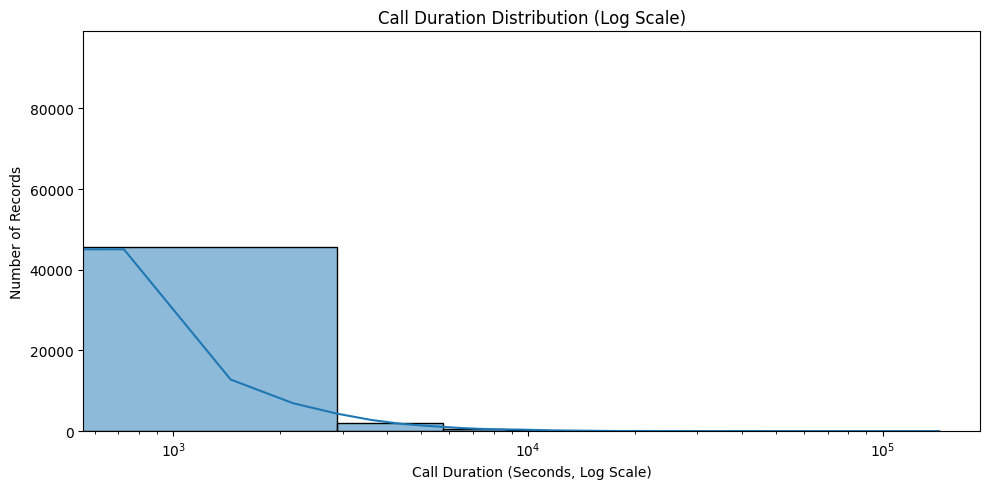

In [ ]:
# Call duration distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df_viz['call_duration'],
    bins=50,
    kde=True
)

plt.xscale('log')

plt.title(
    'Call Duration Distribution (Log Scale)'
)

plt.xlabel(
    'Call Duration (Seconds, Log Scale)'
)

plt.ylabel(
    'Number of Records'
)

plt.tight_layout()

plt.show()

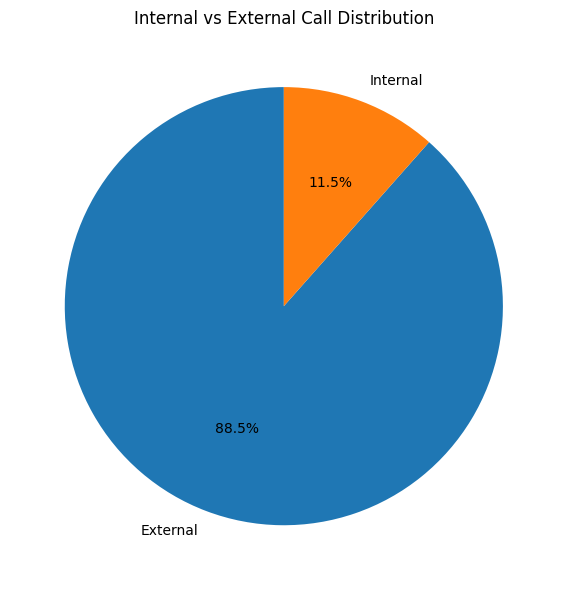

In [ ]:
# Internal vs external call distribution
internal_map = {
    False: 'External',
    True: 'Internal'
}

internal_counts = (
    df_viz['internal']
    .map(internal_map)
    .value_counts(dropna=False)
)

plt.figure(figsize=(6, 6))

plt.pie(
    internal_counts.values,
    labels=internal_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Internal vs External Call Distribution'
)

plt.tight_layout()

plt.show()

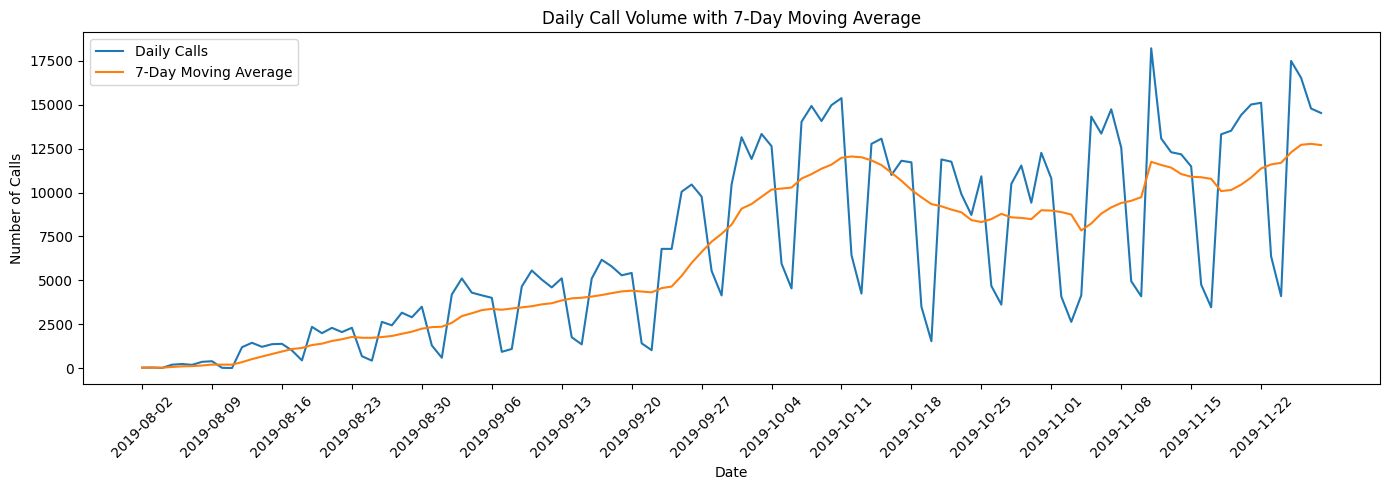

In [ ]:
# Daily call volume
df_viz['date_only'] = df_viz['date'].dt.date

daily_calls = (
    df_viz
    .groupby('date_only')['calls_count']
    .sum()
    .reset_index()
)

daily_calls['date_only'] = pd.to_datetime(
    daily_calls['date_only']
)

daily_calls = daily_calls.sort_values('date_only')

# 7-day moving average
daily_calls['ma7'] = (
    daily_calls['calls_count']
    .rolling(window=7, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_calls['date_only'],
    daily_calls['calls_count'],
    label='Daily Calls'
)

plt.plot(
    daily_calls['date_only'],
    daily_calls['ma7'],
    label='7-Day Moving Average'
)

plt.title(
    'Daily Call Volume with 7-Day Moving Average'
)

plt.xlabel(
    'Date'
)

plt.ylabel(
    'Number of Calls'
)

ticks = daily_calls['date_only'][::7]

plt.xticks(
    ticks,
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.show()

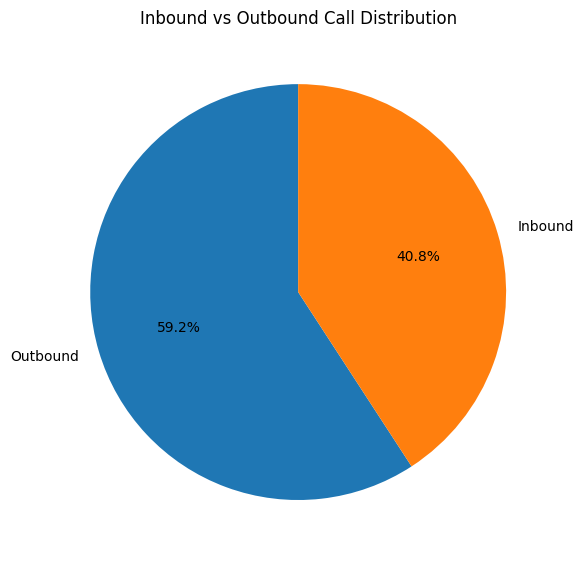

In [ ]:
# Inbound vs outbound call distribution
direction_map = {
    'out': 'Outbound',
    'in': 'Inbound'
}

direction_counts = (
    df_viz['direction']
    .map(direction_map)
    .value_counts()
)

plt.figure(figsize=(6, 6))

plt.pie(
    direction_counts.values,
    labels=direction_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Inbound vs Outbound Call Distribution'
)

plt.tight_layout()

plt.show()

### Visualization Findings

- **Call Duration Distribution (Log Scale):** Call durations showed a highly right-skewed distribution. Most calls were relatively short, while a small number of calls exhibited extremely long durations, creating a pronounced right tail in the distribution. This confirms the presence of outliers and supports the use of robust statistics such as median and IQR throughout the analysis.

- **Internal vs External Calls:** External calls represented approximately **88.5%** of total activity, while internal calls accounted for **11.5%**. Since external calls directly affect customer interactions, operator performance metrics should prioritize customer-facing service quality.

- **Daily Call Volume Trend:** Daily call volume showed an overall upward trend over time, accompanied by recurring peaks and declines that suggest operational or weekly usage patterns. The 7-day moving average highlighted the underlying growth trend while reducing short-term variability.

- **Inbound vs Outbound Calls:** Outbound calls accounted for approximately **59.2%** of total activity, compared with **40.8%** for inbound calls. Because operational inefficiency was defined using inbound missed calls and inbound wait times, subsequent analysis focused primarily on inbound call performance.

## Conclusions

The analysis revealed that overall call center performance remained relatively strong, with an inbound missed call rate of approximately **0.99%**, well below the operational benchmark of **10%**.

However, operator-level analysis showed that performance was not consistent across the workforce. Several operators exceeded the predefined thresholds for missed inbound calls, wait times, or outbound activity, indicating that performance issues were concentrated within specific individuals rather than across the entire system.

Statistical testing confirmed significant differences in inbound wait times between operators. Post-hoc analysis further identified a group of operators with consistently higher wait times, with median wait times ranging from approximately **183 to 953 seconds**, well above the operational target of **180 seconds**.

The analysis also revealed recurring workload peaks throughout the observed period, suggesting that fluctuations in call volume may contribute to increased wait times and operational pressure during high-demand periods.

Overall, the results demonstrate that combining operational KPIs with statistical analysis provides an effective framework for identifying performance gaps, prioritizing interventions, and improving customer service efficiency.

## Recommendations

Based on the findings, the following actions are recommended:

- Prioritize coaching and performance reviews for operators exceeding missed call and wait time thresholds.

- Investigate the root causes behind excessive wait times among the operators identified in the post-hoc analysis, including workload distribution, training gaps, or process inefficiencies.

- Monitor inbound missed call rates and wait times through a KPI dashboard with automated alerts when thresholds are exceeded.

- Review staffing allocation during recurring peak-volume periods to ensure sufficient coverage and reduce customer wait times.

- Evaluate outbound activity levels to confirm that responsibilities and performance expectations are aligned across operators.

- Establish a recurring performance monitoring process to track operator efficiency and measure the effectiveness of improvement initiatives over time.